In [1]:
# Import the libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
import sqlite3

In [2]:
# Read the dataset

df= pd.read_csv('../data/Superstore.csv',  encoding='latin1'
)
print(df.head())


   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2013-152156  09-11-2013  12-11-2013    Second Class    CG-12520   
1       2  CA-2013-152156  09-11-2013  12-11-2013    Second Class    CG-12520   
2       3  CA-2013-138688  13-06-2013  17-06-2013    Second Class    DV-13045   
3       4  US-2012-108966  11-10-2012  18-10-2012  Standard Class    SO-20335   
4       5  US-2012-108966  11-10-2012  18-10-2012  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   Sout

## EDA (Exploratory Data Analysis)

In [3]:
# Data exploration
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [4]:
# Get the correct names columns
df.columns= df.columns.str.strip().str.replace(' ', '_').str.lower()

In [5]:
# Verification of length of the dataset
print(df.shape)
print(' The dataset has 9994 rows and 21 columns.')

(9994, 21)
 The dataset has 9994 rows and 21 columns.


In [6]:
df.describe()

,row_id,postal_code,sales,quantity,discount,profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [7]:
# Get the correct data types for date columns
df['order_date']= pd.to_datetime(df['order_date'],dayfirst=True)
df['ship_date']= pd.to_datetime(df['ship_date'],dayfirst=True)

In [8]:
# Verification of data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   row_id         9994 non-null   int64         
 1   order_id       9994 non-null   object        
 2   order_date     9994 non-null   datetime64[ns]
 3   ship_date      9994 non-null   datetime64[ns]
 4   ship_mode      9994 non-null   object        
 5   customer_id    9994 non-null   object        
 6   customer_name  9994 non-null   object        
 7   segment        9994 non-null   object        
 8   country        9994 non-null   object        
 9   city           9994 non-null   object        
 10  state          9994 non-null   object        
 11  postal_code    9994 non-null   int64         
 12  region         9994 non-null   object        
 13  product_id     9994 non-null   object        
 14  category       9994 non-null   object        
 15  sub-category   9994 n

In [9]:
# Verification of missing values
df.isnull().sum()

row_id           0
order_id         0
order_date       0
ship_date        0
ship_mode        0
customer_id      0
customer_name    0
segment          0
country          0
city             0
state            0
postal_code      0
region           0
product_id       0
category         0
sub-category     0
product_name     0
sales            0
quantity         0
discount         0
profit           0
dtype: int64

In [10]:
# Verification of duplicated values
df.duplicated().sum()
print("No duplicated values found.")

No duplicated values found.


In [11]:
# Range of dates in the dataset
print(
    f"Study period: {df['order_date'].min()} - {df['order_date'].max()}"
)

Study period: 2011-01-04 00:00:00 - 2014-12-31 00:00:00


In [12]:
df.value_counts()

row_id  order_id        order_date  ship_date   ship_mode       customer_id  customer_name     segment      country        city         state          postal_code  region   product_id       category         sub-category  product_name                                                               sales    quantity  discount  profit   
1       CA-2013-152156  2013-11-09  2013-11-12  Second Class    CG-12520     Claire Gute       Consumer     United States  Henderson    Kentucky       42420        South    FUR-BO-10001798  Furniture        Bookcases     Bush Somerset Collection Bookcase                                          261.960  2         0.0        41.9136     1
6666    CA-2013-115483  2013-07-15  2013-07-19  Second Class    JS-15880     John Stevenson    Consumer     United States  Irving       Texas          75061        Central  OFF-PA-10001497  Office Supplies  Paper         Xerox 1914                                                                 219.840  5         0.2       

In [13]:
# Verification of outliers in the dataset
df[['sales','profit','quantity']].describe()

,sales,profit,quantity
count,9994.000000,9994.000000,9994.000000
mean,229.858001,28.656896,3.789574
std,623.245101,234.260108,2.225110
min,0.444000,-6599.978000,1.000000
25%,17.280000,1.728750,2.000000
50%,54.490000,8.666500,3.000000
75%,209.940000,29.364000,5.000000
max,22638.480000,8399.976000,14.000000


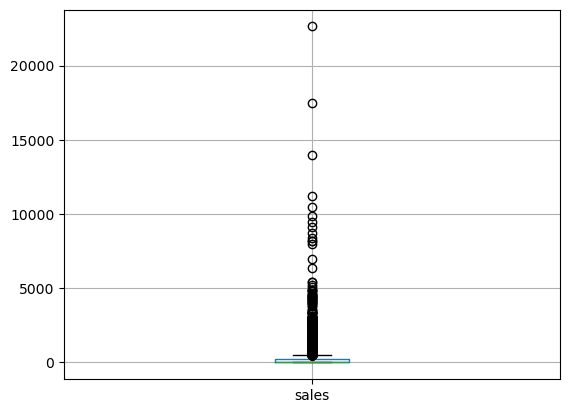

In [14]:
# Visualization of outliers in the dataset 
df.boxplot(column='sales')

plt.show()

In [15]:
# Save the cleaned dataset
df.to_csv("clean_data.csv", index=False)

In [16]:
# Connect to the SQLite database
conn = sqlite3.connect('sales_analysis.db')